# Restaurant Analytics — What Makes a Restaurant Successful on Zomato?
## Bangalore Food Market Analysis using Python

## Executive Summary

### Business Context
Zomato hosts thousands of restaurants across Bangalore competing for 
customer attention and reviews. This analysis investigates what 
separates high-performing restaurants from low-performing ones across 
four key dimensions — cuisine, online presence, restaurant type, 
pricing, and location.

### Central Question
What factors most strongly predict a restaurant's rating and customer 
engagement on Zomato Bangalore?

### Key Findings
1. **Cuisine** — Mediterranean and European cuisines rate highest (4.2+) 
   but Continental and Café attract the most customers. Popularity and 
   quality occupy different positions in Bangalore's food market.

2. **Online Ordering** — Restaurants accepting online orders attract 75% 
   more votes (9.3M vs 5.3M) and rate slightly higher (3.72 vs 3.66). 
   Online presence is a visibility strategy, not just a convenience feature.

3. **Restaurant Type** — Casual Dining + Bar rates highest (4.08) while 
   Delivery and Quick Bites rate lowest (3.57, 3.55). High volume formats 
   trade experience quality for footfall.

4. **Pricing** — Luxury restaurants (1000+) rate highest (4.13) and 
   receive 16x more votes per restaurant than budget ones (1,225 vs 74). 
   Premium positioning creates a compounding visibility advantage.

5. **Location** — Lavelle Road and Koramangala dominate top ratings. 
   Peripheral IT corridors like Electronic City and Marathahalli 
   consistently underperform central dining destinations.

### Overall Conclusion
Restaurant success on Zomato Bangalore is driven by a compounding 
premium effect — higher price, better location, and sit-down experience 
consistently outperform budget, delivery, and peripheral alternatives 
on both ratings and engagement. Online ordering is the one low-cost 
lever any restaurant can pull immediately to increase visibility.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
df=pd.read_csv("/kaggle/input/datasets/himanshupoddar/zomato-bangalore-restaurants/zomato.csv")
df.head(3)

,url,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),reviews_list,menu_item,listed_in(type),listed_in(city)
0,https://www.zomato.com/bangalore/jalsa-banasha...,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1/5,775,080 42297555\r\n+91 9743772233,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800,"[('Rated 4.0', 'RATED\n A beautiful place to ...",[],Buffet,Banashankari
1,https://www.zomato.com/bangalore/spice-elephan...,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,4.1/5,787,080 41714161,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800,"[('Rated 4.0', 'RATED\n Had been here for din...",[],Buffet,Banashankari
2,https://www.zomato.com/SanchurroBangalore?cont...,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,Yes,No,3.8/5,918,+91 9663487993,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800,"[('Rated 3.0', ""RATED\n Ambience is not that ...",[],Buffet,Banashankari


In [3]:
df.shape

(51717, 17)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51717 entries, 0 to 51716
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   url                          51717 non-null  object
 1   address                      51717 non-null  object
 2   name                         51717 non-null  object
 3   online_order                 51717 non-null  object
 4   book_table                   51717 non-null  object
 5   rate                         43942 non-null  object
 6   votes                        51717 non-null  int64 
 7   phone                        50509 non-null  object
 8   location                     51696 non-null  object
 9   rest_type                    51490 non-null  object
 10  dish_liked                   23639 non-null  object
 11  cuisines                     51672 non-null  object
 12  approx_cost(for two people)  51371 non-null  object
 13  reviews_list                 51

In [5]:
df.describe()

,votes
count,51717.000000
mean,283.697527
std,803.838853
min,0.000000
25%,7.000000
50%,41.000000
75%,198.000000
max,16832.000000


In [6]:
df.isnull().sum()

url                                0
address                            0
name                               0
online_order                       0
book_table                         0
rate                            7775
votes                              0
phone                           1208
location                          21
rest_type                        227
dish_liked                     28078
cuisines                          45
approx_cost(for two people)      346
reviews_list                       0
menu_item                          0
listed_in(type)                    0
listed_in(city)                    0
dtype: int64

In [7]:
df['rest_type'].value_counts()

rest_type
Quick Bites                   19132
Casual Dining                 10330
Cafe                           3732
Delivery                       2604
Dessert Parlor                 2263
                              ...  
Dessert Parlor, Kiosk             2
Dessert Parlor, Food Court        2
Food Court, Beverage Shop         2
Sweet Shop, Dessert Parlor        1
Quick Bites, Kiosk                1
Name: count, Length: 93, dtype: int64

In [8]:
print(df['online_order'].unique())
print(df['book_table'].unique())
print(df['approx_cost(for two people)'].unique()[:20])

['Yes' 'No']
['Yes' 'No']
['800' '300' '600' '700' '550' '500' '450' '650' '400' '900' '200' '750'
 '150' '850' '100' '1,200' '350' '250' '950' '1,000']


In [9]:
print(df['rate'].unique()[:20])

['4.1/5' '3.8/5' '3.7/5' '3.6/5' '4.6/5' '4.0/5' '4.2/5' '3.9/5' '3.1/5'
 '3.0/5' '3.2/5' '3.3/5' '2.8/5' '4.4/5' '4.3/5' 'NEW' '2.9/5' '3.5/5' nan
 '2.6/5']


In [10]:
print(df.dtypes)

url                            object
address                        object
name                           object
online_order                   object
book_table                     object
rate                           object
votes                           int64
phone                          object
location                       object
rest_type                      object
dish_liked                     object
cuisines                       object
approx_cost(for two people)    object
reviews_list                   object
menu_item                      object
listed_in(type)                object
listed_in(city)                object
dtype: object


#### Data Cleaning

In [11]:
df_new=df['rate'].str.split('/',n=None,expand=True)
df_new=df_new[0]
df_new

0         4.1
1         4.1
2         3.8
3         3.7
4         3.8
         ... 
51712    3.6 
51713     NaN
51714     NaN
51715    4.3 
51716    3.4 
Name: 0, Length: 51717, dtype: object

In [12]:
df_new=df_new.replace('NEW',np.nan)
df_new=pd.to_numeric(df_new,errors='coerce')

In [13]:
df_new

0        4.1
1        4.1
2        3.8
3        3.7
4        3.8
        ... 
51712    3.6
51713    NaN
51714    NaN
51715    4.3
51716    3.4
Name: 0, Length: 51717, dtype: float64

In [14]:
df['rate']=df_new

In [15]:
df.describe()

,rate,votes
count,41665.000000,51717.000000
mean,3.700449,283.697527
std,0.440513,803.838853
min,1.800000,0.000000
25%,3.400000,7.000000
50%,3.700000,41.000000
75%,4.000000,198.000000
max,4.900000,16832.000000


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51717 entries, 0 to 51716
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   url                          51717 non-null  object 
 1   address                      51717 non-null  object 
 2   name                         51717 non-null  object 
 3   online_order                 51717 non-null  object 
 4   book_table                   51717 non-null  object 
 5   rate                         41665 non-null  float64
 6   votes                        51717 non-null  int64  
 7   phone                        50509 non-null  object 
 8   location                     51696 non-null  object 
 9   rest_type                    51490 non-null  object 
 10  dish_liked                   23639 non-null  object 
 11  cuisines                     51672 non-null  object 
 12  approx_cost(for two people)  51371 non-null  object 
 13  reviews_list    

In [17]:
df['approx_cost(for two people)']=df['approx_cost(for two people)'].str.replace(',','')
df['approx_cost(for two people)']

0         800
1         800
2         800
3         300
4         600
         ... 
51712    1500
51713     600
51714    2000
51715    2500
51716    1500
Name: approx_cost(for two people), Length: 51717, dtype: object

In [18]:
df['approx_cost(for two people)']=pd.to_numeric(df['approx_cost(for two people)'],errors='coerce')
df['approx_cost(for two people)'].describe()

count    51371.000000
mean       555.431566
std        438.850728
min         40.000000
25%        300.000000
50%        400.000000
75%        650.000000
max       6000.000000
Name: approx_cost(for two people), dtype: float64

In [19]:
df_clean=df.dropna(subset=['rate']).copy()
print("Total Count before dropping:",len(df))
print("Total Count after dropping:",len(df_clean))

Total Count before dropping: 51717
Total Count after dropping: 41665


In [20]:
print(df_clean[['rate','approx_cost(for two people)']].dtypes)

rate                           float64
approx_cost(for two people)    float64
dtype: object


In [21]:
print(df_clean[['rate','approx_cost(for two people)']].describe())

               rate  approx_cost(for two people)
count  41665.000000                 41418.000000
mean       3.700449                   603.268048
std        0.440513                   464.327857
min        1.800000                    40.000000
25%        3.400000                   300.000000
50%        3.700000                   500.000000
75%        4.000000                   700.000000
max        4.900000                  6000.000000


In [22]:
df_clean['listed_in(type)'].value_counts()

listed_in(type)
Delivery              20649
Dine-out              14207
Desserts               2732
Cafes                  1526
Drinks & nightlife     1055
Buffet                  855
Pubs and bars           641
Name: count, dtype: int64

In [23]:
cuisines_split=df_clean['cuisines'].str.split(',').explode().str.strip()
cuisines_split.value_counts().head(10)

cuisines
North Indian    17406
Chinese         13005
South Indian     6394
Fast Food        6360
Continental      5245
Biryani          5071
Cafe             4828
Desserts         4537
Beverages        3873
Italian          3213
Name: count, dtype: int64

In [24]:
cuisines_df=df[['cuisines','rate','votes']].copy()
cuisines_df=cuisines_df.dropna(subset=['cuisines'])

In [25]:
cuisines_df.head(2)

,cuisines,rate,votes
0,"North Indian, Mughlai, Chinese",4.1,775
1,"Chinese, North Indian, Thai",4.1,787


In [26]:
cuisines_df['cuisines']=cuisines_df['cuisines'].str.split(',')
cuisines_df=cuisines_df.explode('cuisines')
cuisines_df['cuisines']=cuisines_df['cuisines'].str.strip()

In [27]:
cuisines_df.head(2)

,cuisines,rate,votes
0,North Indian,4.1,775
0,Mughlai,4.1,775


In [28]:
cuisine_counts=cuisines_df['cuisines'].value_counts()
value_count=cuisine_counts[cuisine_counts>=500].index
cusine_filtered=cuisines_df[cuisines_df['cuisines'].isin(value_count)]

In [29]:
df_new=cusine_filtered.groupby('cuisines').agg(
    {'rate': 'mean',
    'votes':'sum'}
).sort_values(by='rate',ascending=False)
df_new=df_new.reset_index()
df_new.head(10)

,cuisines,rate,votes
0,Mediterranean,4.213187,948507
1,European,4.165793,1025739
2,Asian,4.135631,1187992
3,Steak,4.090681,880628
4,American,4.070659,2046558
5,Salad,4.065254,1160487
6,BBQ,4.053846,1016072
7,Finger Food,3.998307,1158598
8,Thai,3.987290,812254
9,Continental,3.964099,4370661


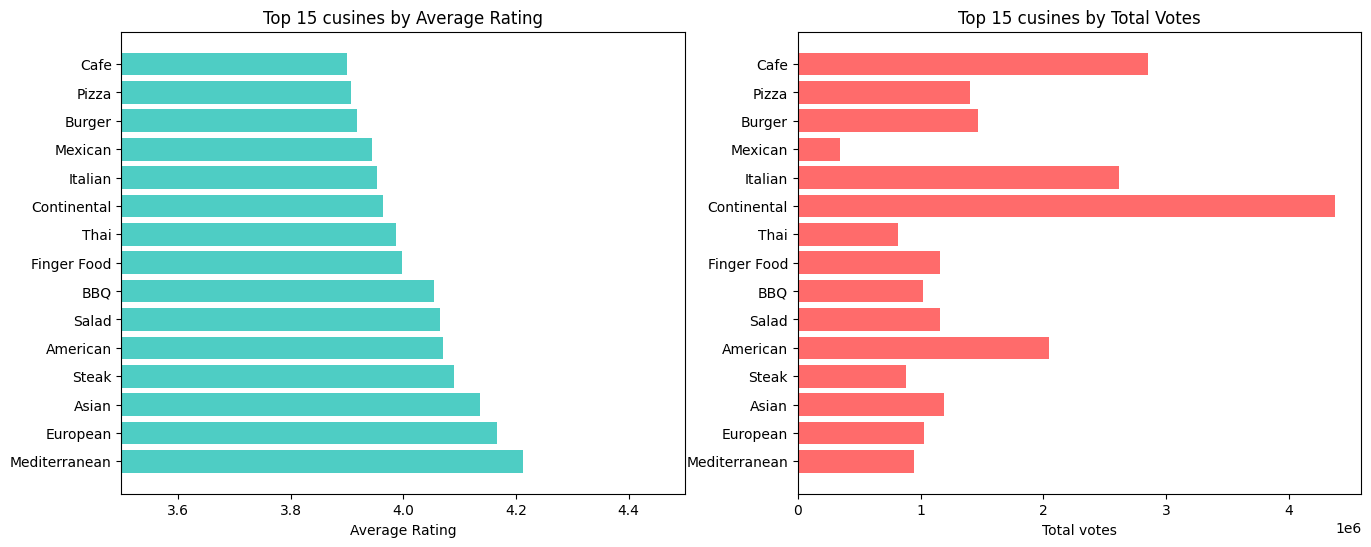

In [30]:
fig,axes=plt.subplots(1,2,figsize=(16,6))

top15=df_new.head(15)


#Average Rating
axes[0].barh(top15['cuisines'],top15['rate'],color='#4ECDC4')
axes[0].set_title('Top 15 cusines by Average Rating')
axes[0].set_xlabel('Average Rating')
axes[0].set_xlim(3.5, 4.5)

#Total Votes
axes[1].barh(top15['cuisines'],top15['votes'], color='#FF6B6B')
axes[1].set_title('Top 15 cusines by Total Votes')
axes[1].set_xlabel('Total votes')

plt.show()

## Finding 1 — Popular Cuisines Are Not the Highest Rated Ones

Continental cuisine attracts the highest customer volume (4.3M+ votes) 
but rates only 3.96 on average. Mediterranean and European cuisines 
consistently rate highest (4.2+) but attract significantly fewer customers.

Insight for restaurant owners: High volume and high quality occupy 
different positions in Bangalore's food market. A restaurant targeting 
premium positioning should consider Mediterranean or European cuisine. 
A restaurant targeting volume should focus on Continental or Café.

In [31]:
online_order_df=df_clean.groupby('online_order').agg(
    {
      'rate':'mean',
        'votes': 'sum'
    }
).round(2)
online_order_df=online_order_df.reset_index()
online_order_df

,online_order,rate,votes
0,No,3.66,5313744
1,Yes,3.72,9337879


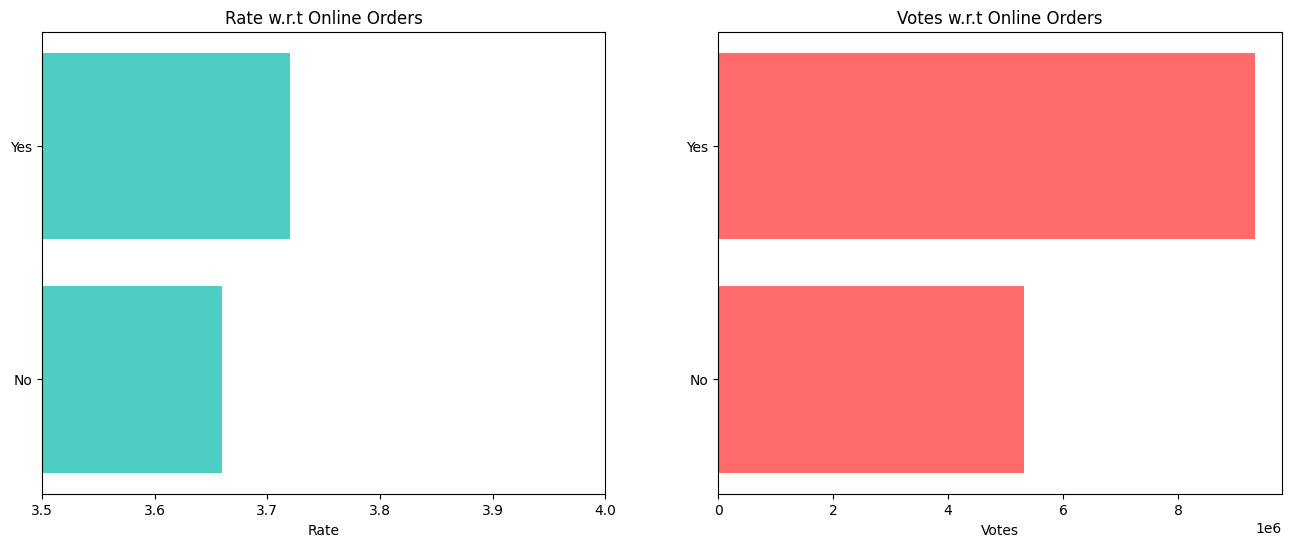

In [32]:
fig,axes=plt.subplots(1,2,figsize=(16,6))

#rating
axes[0].barh(online_order_df['online_order'],online_order_df['rate'],color='#4ECDC4'),
axes[0].set_title("Rate w.r.t Online Orders")
axes[0].set_xlabel('Rate')
axes[0].set_xlim(3.5,4.0)

#total votes
axes[1].barh(online_order_df['online_order'],online_order_df['votes'],color='#FF6B6B'),
axes[1].set_title("Votes w.r.t Online Orders")
axes[1].set_xlabel('Votes')



plt.show()

## Finding 2 — Online Ordering Is Strongly Associated With Visibility and Satisfaction

Restaurants accepting online orders average a rating of 3.72 vs 3.66 
for those that don't. More strikingly, they attract 75% more votes 
(9.3M vs 5.3M).

Insight: For a new restaurant, enabling online ordering is not just 
a convenience feature — it is a visibility and engagement strategy. 
The volume gap suggests online ordering dramatically increases 
customer touchpoints and reviews.

In [33]:
rest_type_df=df_clean['rest_type'].value_counts()
value_counts=rest_type_df[rest_type_df>=500].index
rest_type_filtered=df_clean[df_clean['rest_type'].isin(value_counts)]

In [35]:
df_rest_type=rest_type_filtered.groupby('rest_type').agg(
    {'rate':'mean',
    'votes':'sum'}
).sort_values(by='rate',ascending=False)
df_rest_type=df_rest_type.reset_index()
df_rest_type.head(10)

,rest_type,rate,votes
0,"Casual Dining, Bar",4.079009,1221947
1,Dessert Parlor,3.875483,323258
2,Cafe,3.847342,1454188
3,Casual Dining,3.740398,4536816
4,Bar,3.737942,284802
5,Beverage Shop,3.626324,30201
6,Bakery,3.607955,35584
7,Delivery,3.569286,223766
8,Quick Bites,3.546113,1476809
9,"Takeaway, Delivery",3.513622,90276


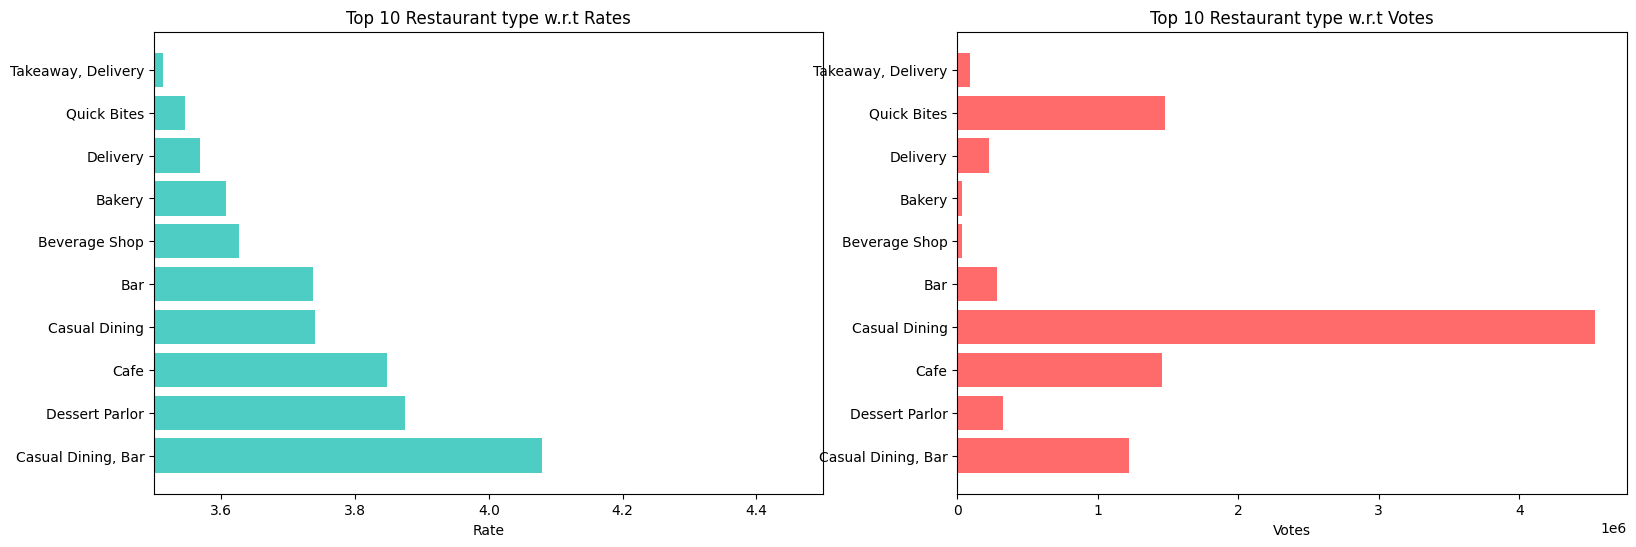

In [44]:
fig,axes=plt.subplots(1,2,figsize=(19,6))

#rating
axes[0].barh(df_rest_type['rest_type'],df_rest_type['rate'],color='#4ECDC4'),
axes[0].set_title("Top 10 Restaurant type w.r.t Rates")
axes[0].set_xlabel('Rate')
axes[0].set_xlim(3.5,4.5)

#total votes
axes[1].barh(df_rest_type['rest_type'],df_rest_type['votes'],color='#FF6B6B'),
axes[1].set_title("Top 10 Restaurant type w.r.t Votes")
axes[1].set_xlabel('Votes')



plt.show()

## Finding 3 — Restaurant Type Reveals a Clear Quality vs Volume Trade-off

Casual Dining + Bar scores highest (4.08) while Quick Bites and 
Delivery score lowest (3.55, 3.57). However Quick Bites attracts 
1.47M votes and Casual Dining dominates at 4.5M votes.

Key insights:
- Quick Bites trades experience for volume — high footfall but 
  lower satisfaction due to transactional nature of the visit
- Delivery restaurants rate lowest because experience depends on 
  logistics outside the restaurant's control — packaging, timing, 
  and temperature all affect ratings post-kitchen
- Casual Dining + Bar represents the sweet spot — premium experience 
  drives both high ratings and strong engagement

Recommendation: Restaurants prioritising ratings should invest in 
the sit-down experience. Restaurants prioritising volume should 
target Quick Bites format in high foot-traffic areas.

In [45]:
bins = [0, 300, 600, 1000, 6000]
labels = ['Budget\n(under 300)', 'Mid-range\n(300-600)', 
          'Premium\n(600-1000)', 'Luxury\n(1000+)']

df_clean['price_range'] = pd.cut(df_clean['approx_cost(for two people)'], 
                                  bins=bins, labels=labels)

In [48]:
df_price=df_clean.groupby('price_range').agg(
    {'rate':'mean',
    'votes':'sum'}
).sort_values(by='rate',ascending=False)
df_price=df_price.reset_index()
df_price.head(10)

/tmp/ipykernel_57/1880266044.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_price=df_clean.groupby('price_range').agg(


,price_range,rate,votes
0,Luxury\n(1000+),4.129601,6289184
1,Premium\n(600-1000),3.804262,4004724
2,Mid-range\n(300-600),3.616283,3344791
3,Budget\n(under 300),3.567165,929089


In [49]:
df_price=df_clean.groupby('price_range').agg(
    {'rate':'mean',
    'votes':'sum'}
)
df_price=df_price.reset_index()
df_price.head(10)

/tmp/ipykernel_57/145143015.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_price=df_clean.groupby('price_range').agg(


,price_range,rate,votes
0,Budget\n(under 300),3.567165,929089
1,Mid-range\n(300-600),3.616283,3344791
2,Premium\n(600-1000),3.804262,4004724
3,Luxury\n(1000+),4.129601,6289184


In [50]:
print(df_clean['price_range'].value_counts())

price_range
Mid-range\n(300-600)    15906
Budget\n(under 300)     12587
Premium\n(600-1000)      7790
Luxury\n(1000+)          5135
Name: count, dtype: int64


In [51]:
price_analysis = df_clean.groupby('price_range').agg(
    avg_rating=('rate', 'mean'),
    total_votes=('votes', 'sum'),
    restaurant_count=('rate', 'count')
).round(2)

price_analysis['votes_per_restaurant'] = (
    price_analysis['total_votes'] / price_analysis['restaurant_count']
).round(0)

print(price_analysis)

                      avg_rating  total_votes  restaurant_count  \
price_range                                                       
Budget\n(under 300)         3.57       929089             12587   
Mid-range\n(300-600)        3.62      3344791             15906   
Premium\n(600-1000)         3.80      4004724              7790   
Luxury\n(1000+)             4.13      6289184              5135   

                      votes_per_restaurant  
price_range                                 
Budget\n(under 300)                   74.0  
Mid-range\n(300-600)                 210.0  
Premium\n(600-1000)                  514.0  
Luxury\n(1000+)                     1225.0  


/tmp/ipykernel_57/1740897423.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  price_analysis = df_clean.groupby('price_range').agg(


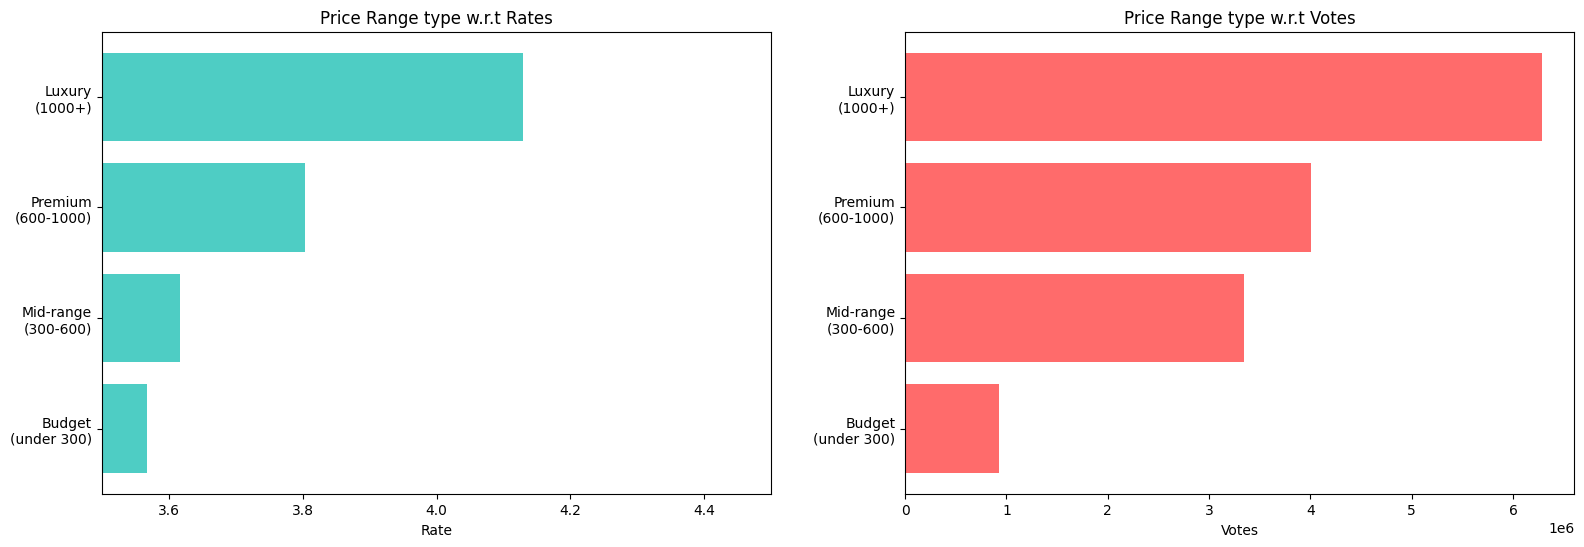

In [65]:
fig,axes=plt.subplots(1,2,figsize=(19,6))

#rating
axes[0].barh(df_price['price_range'],df_price['rate'],color='#4ECDC4'),
axes[0].set_title("Price Range type w.r.t Rates")
axes[0].set_xlabel('Rate')
axes[0].set_xlim(3.5,4.5)

#total votes
axes[1].barh(df_price['price_range'],df_price['votes'],color='#FF6B6B'),
axes[1].set_title("Price Range type w.r.t Votes")
axes[1].set_xlabel('Votes')



plt.show()

## Finding 4 — Price and Engagement Have a Dramatic Linear Relationship

Higher price tier = higher ratings AND dramatically more engagement:
- Budget restaurants average 74 votes each
- Luxury restaurants average 1,225 votes each — a 16x difference

This is not just about taste — it reflects fundamentally different 
customer behavior. Luxury diners are more engaged, more likely to 
review, and more satisfied with their experience.

Insight: The data suggests that moving upmarket is not just a revenue 
decision — it is a visibility and reputation strategy. Premium 
positioning on Zomato creates a compounding advantage where higher 
spend attracts more reviews which attracts more customers.

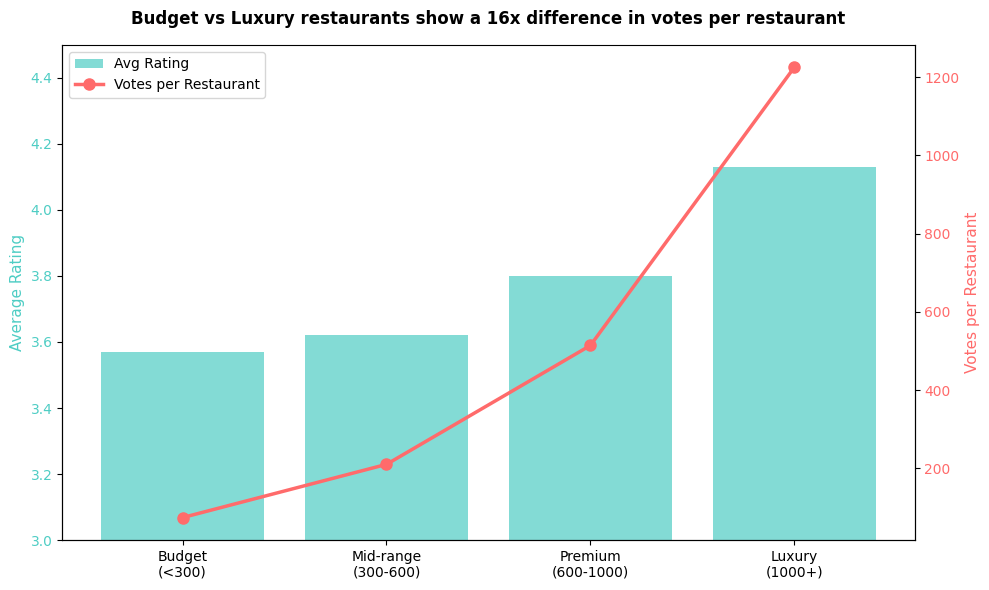

In [53]:
fig, ax1 = plt.subplots(figsize=(10, 6))

price_labels = ['Budget\n(<300)', 'Mid-range\n(300-600)', 
                'Premium\n(600-1000)', 'Luxury\n(1000+)']

# rating
ax1.bar(price_labels, price_analysis['avg_rating'], 
        color='#4ECDC4', alpha=0.7, label='Avg Rating')
ax1.set_ylabel('Average Rating', color='#4ECDC4', fontsize=11)
ax1.set_ylim(3.0, 4.5)
ax1.tick_params(axis='y', labelcolor='#4ECDC4')

#votes per restaurant
ax2 = ax1.twinx()
ax2.plot(price_labels, price_analysis['votes_per_restaurant'], 
         color='#FF6B6B', linewidth=2.5, marker='o', 
         markersize=8, label='Votes per Restaurant')
ax2.set_ylabel('Votes per Restaurant', color='#FF6B6B', fontsize=11)
ax2.tick_params(axis='y', labelcolor='#FF6B6B')

ax1.set_title('Budget vs Luxury restaurants show a 16x difference in votes per restaurant',
              fontsize=12, fontweight='bold', pad=15)
ax1.spines['top'].set_visible(False)


lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.show()

In [54]:
df_location=df_clean['location'].value_counts()
value_counts=df_location[df_location>=200].index
location_filtered=df_clean[df_clean['location'].isin(value_counts)]

In [62]:
df_location=location_filtered.groupby('location').agg(
    {'rate':'mean',
    'votes':'sum'}
).sort_values(by='rate',ascending=False)
df_location=df_location.reset_index()
df_location

,location,rate,votes
0,Lavelle Road,4.142505,506186
1,St. Marks Road,4.017201,266099
2,Koramangala 5th Block,4.005821,2219506
3,Church Street,3.992125,594979
4,Koramangala 4th Block,3.918668,685156
5,Cunningham Road,3.901053,287873
6,Residency Road,3.863636,291954
7,MG Road,3.855857,432111
8,Koramangala 7th Block,3.850377,495324
9,Indiranagar,3.828154,1196007


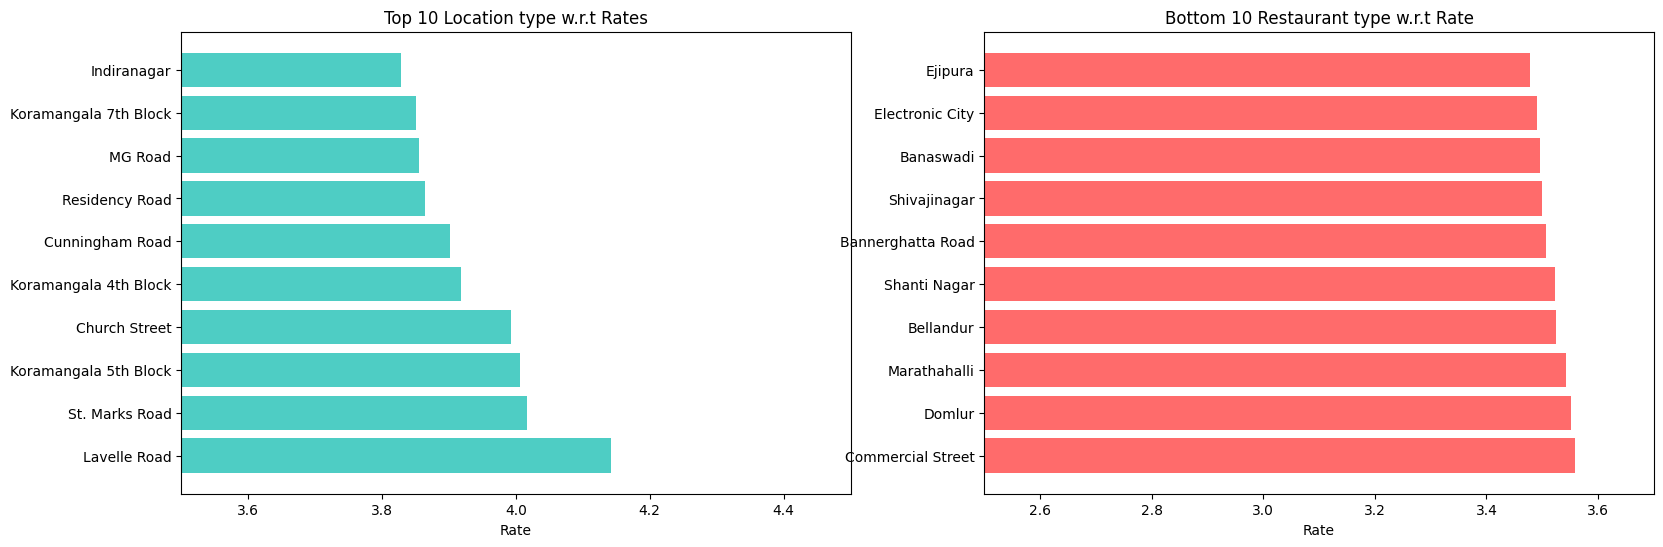

In [64]:
fig,axes=plt.subplots(1,2,figsize=(19,6))

top10=df_location.head(10)
#rating
axes[0].barh(top10['location'],top10['rate'],color='#4ECDC4'),
axes[0].set_title("Top 10 Location type w.r.t Rates")
axes[0].set_xlabel('Rate')
axes[0].set_xlim(3.5,4.5)


bottom10=df_location.tail(10)
axes[1].barh(bottom10['location'],bottom10['rate'],color='#FF6B6B'),
axes[1].set_title("Bottom 10 Restaurant type w.r.t Rate")
axes[1].set_xlabel('Rate')
axes[1].set_xlim(2.5,3.7)



plt.show()

## Finding 5 — Location Reflects the Premium Positioning Pattern

Top rated areas: Lavelle Road (4.14), St. Marks Road (4.02), 
Koramangala blocks (3.99-4.00)
Lowest rated areas: Electronic City (3.49), Marathahalli (3.54), 
Bellandur (3.53)

Insight: Premium central locations consistently outperform peripheral 
IT corridors. This aligns with Finding 4 — upmarket areas attract 
higher spending customers who are more engaged reviewers. 
Koramangala's dominance across multiple blocks confirms it as 
Bangalore's highest quality dining destination.